In [1]:
import os 
import glob
import numpy as np 
import matplotlib.pyplot as plt
import sklearn as sk 
import librosa as lb 
import seaborn as sb 
import torch as to
import pathlib as pt
from pathlib import Path
from IPython.display import Audio
import librosa.display
import re
from functools import reduce
import scipy as sc

/home/vd/.local/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Βήμα 2

In [2]:
directory = '/home/vd/mat/Πρωτυπα/Lab2/data/digits'
r = re.compile("([a-zA-Z]+)([0-9]+)")
dictionary = {"zero":0, "one":1, "two":2, "three":3, "four":4, "five":5, "six":6, "seven":7, "eight":8, "nine":9}

def dataparser(directory):
    files = lb.util.find_files(directory)
    faudio= []
    fspeaker = []
    fdigit = []
    digit=dict()
    for f in range(len(files)):
        k = files[f].split('/')[-1]
        faudio.append(lb.load(files[f],sr = None))
        k = k.split('.')[0]
        m = r.match(k)
        fspeaker.append(m.group(2))
        fdigit.append(m.group(1))
        digit =[dictionary[key] for key in fdigit] 
    return  fspeaker, digit, faudio

In [3]:
fspeaker, digit, faudio = dataparser("/home/vd/mat/Πρωτυπα/Lab2/data/digits")

In [4]:
print(os.getcwd())

/home/vd/mat/Πρωτυπα/Lab2


Βήμα 3

In [5]:
a = np.asarray(faudio[0][0])
a

array([-0.0007019 , -0.00088501, -0.00048828, ...,  0.00088501,
        0.00112915,  0.00091553], dtype=float32)

In [6]:
def feature_extract(a):
    fs = 16000//2
    window = 25*fs//1000
    step = 10*fs// 1000
    frames = [
        lb.feature.mfcc(np.asarray(a[i][0]),fs, n_fft=window, hop_length = window-step, n_mfcc= 13)
        for i in range(len(a))]
    delta_mfcc  = [lb.feature.delta(f) for f in frames]
    delta2_mfcc = [lb.feature.delta(f, order=2) for f in frames]
    return frames, delta_mfcc, delta2_mfcc

frames, delta_mfcc, delta2_mfcc = feature_extract(faudio)


/tmp/ipykernel_2318/231061602.py:6: FutureWarning: Pass y=[-0.0007019  -0.00088501 -0.00048828 ...  0.00088501  0.00112915
  0.00091553], sr=8000 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  lb.feature.mfcc(np.asarray(a[i][0]),fs, n_fft=window, hop_length = window-step, n_mfcc= 13)
/home/vd/.local/lib/python3.8/site-packages/librosa/util/decorators.py:88: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  return f(*args, **kwargs)
/tmp/ipykernel_2318/231061602.py:6: FutureWarning: Pass y=[ 9.1552734e-05 -3.0517578e-05 -2.7465820e-04 ...  6.4086914e-04
  1.1596680e-03  1.3427734e-03], sr=8000 as keyword args. From version 0.10 passing these as positional arguments will result in an error
  lb.feature.mfcc(np.asarray(a[i][0]),fs, n_fft=window, hop_length = window-step, n_mfcc= 13)
/tmp/ipykernel_2318/231061602.py:6: 

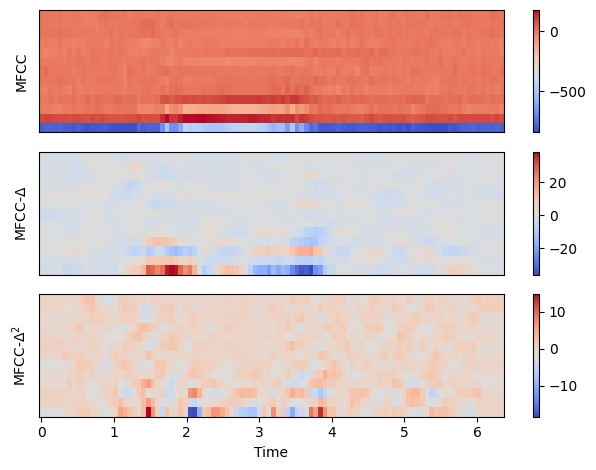

In [7]:
plt.subplot(3,1,1)
librosa.display.specshow(frames[0])
plt.ylabel('MFCC')
plt.colorbar()

plt.subplot(3,1,2)
librosa.display.specshow(delta_mfcc[0])
plt.ylabel('MFCC-$\Delta$')
plt.colorbar()

plt.subplot(3,1,3)
librosa.display.specshow(delta2_mfcc[0], sr=8000, x_axis='time')
plt.ylabel('MFCC-$\Delta^2$')
plt.colorbar()

plt.tight_layout()

# Stacking these 3 tables together into one matrix
M = np.vstack([frames[0], delta_mfcc[0], delta2_mfcc[0]])

                                                                Βήμα 4 

In [8]:
n1 = 6
n2 = 3

k1 = []
k2 = []
for i in range(len(digit)):
    if(digit[i]==n1):
            #k.append(i)
            k1.append(np.asarray(frames[i][0]))
            k2.append(np.asarray(frames[i][1]))
            #print(fspeaker[i])

k11 = []
k22 = []
k = []
for i in range(len(digit)):
    if(digit[i]==n2):
            k.append(i)
            k11.append(np.asarray(frames[i][0]))
            k22.append(np.asarray(frames[i][1]))
            #print(fspeaker[i])
print(k)
faudio[89][0]



[103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117]


array([ 6.1035156e-05,  3.0517578e-05, -9.1552734e-05, ...,
       -6.1035156e-05, -6.1035156e-05,  3.0517578e-04], dtype=float32)

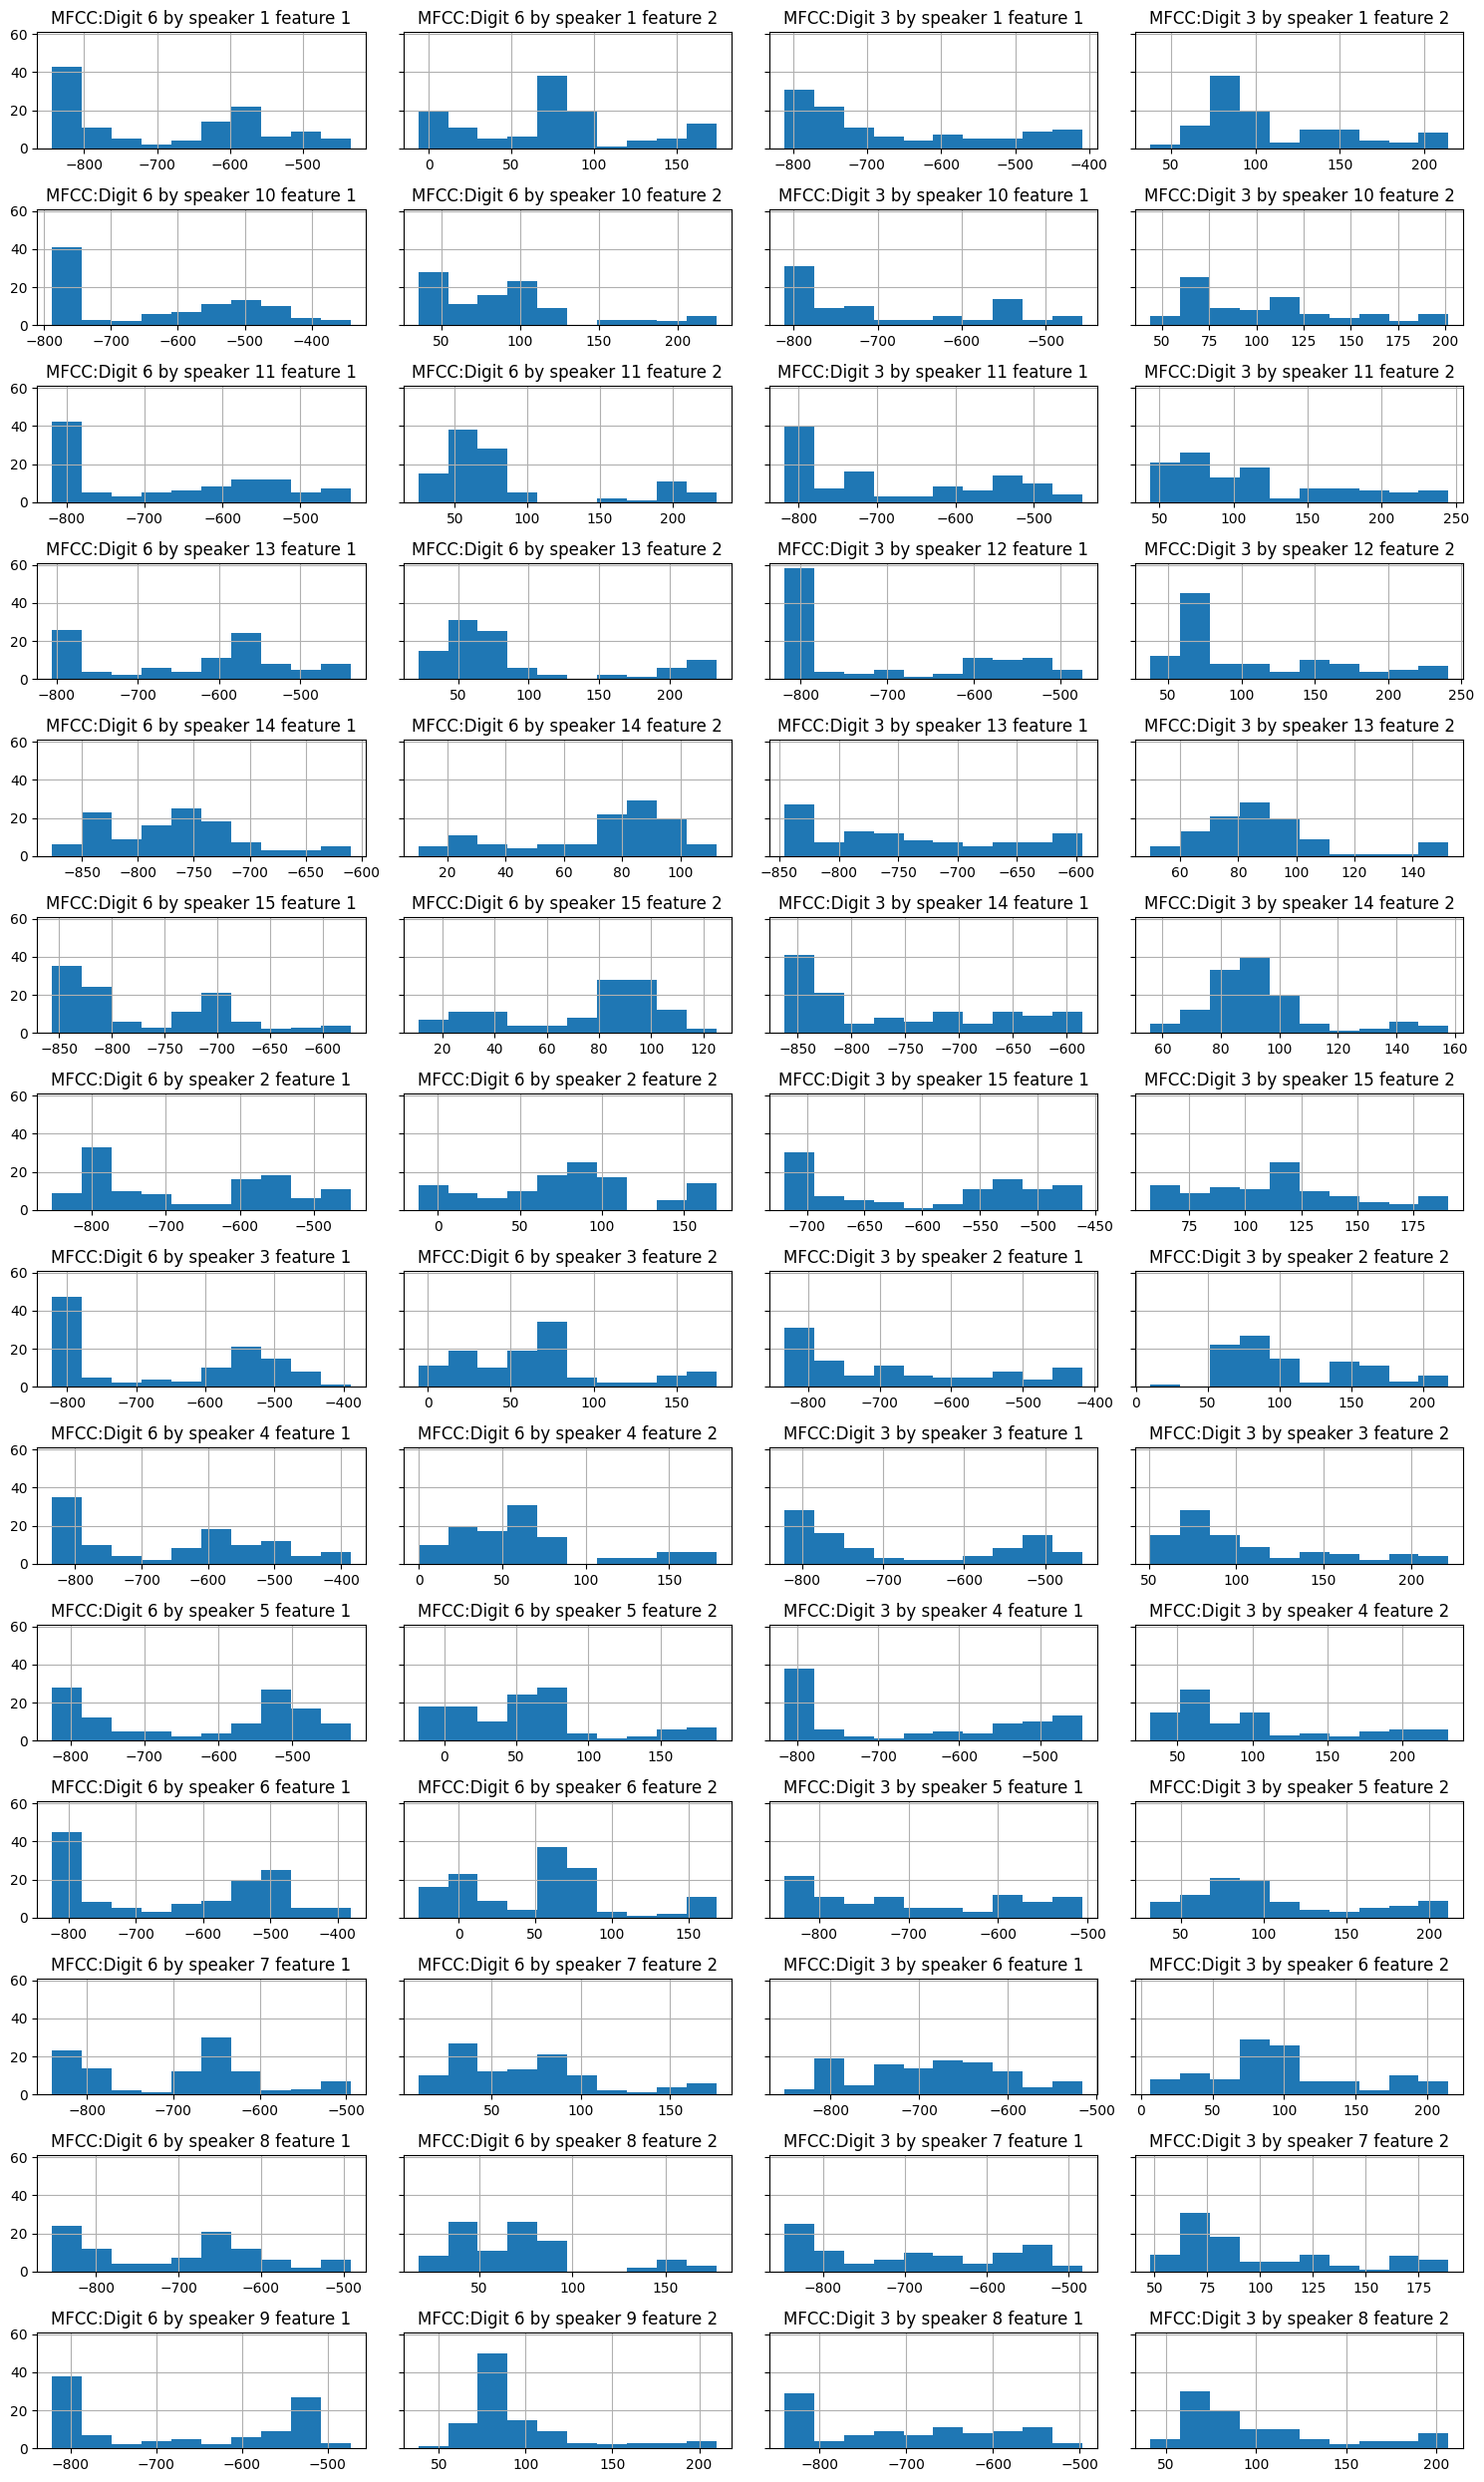

In [9]:
fig, axs = plt.subplots(14, 4,figsize=(15, 25), sharey=True)

for i in range(0,14,1):
    #[1,i] = plt.subplot(14, 2, 1)
    axs[i,0].hist(k1[i])
    axs[i,0].set_title("MFCC:Digit " + str(n1)+ " by speaker " +str(fspeaker[89+i]) +" feature 1")
    axs[i,0].grid()
    #axs[2,i] = plt.subplot(14,2,2)
    axs[i,1].hist(k2[i])
    axs[i,1].set_title("MFCC:Digit " + str(n1)+ " by speaker " +str(fspeaker[89+i]) +" feature 2")
    axs[i,1].grid()
    #[1,i] = plt.subplot(14, 2, 1)
    axs[i,2].hist(k11[i])
    axs[i,2].set_title("MFCC:Digit " + str(n2)+ " by speaker " +str(fspeaker[103+i]) +" feature 1")
    axs[i,2].grid()
    #axs[2,i] = plt.subplot(14,2,2)
    axs[i,3].hist(k22[i])
    axs[i,3].set_title("MFCC:Digit " + str(n2)+ " by speaker " +str(fspeaker[103+i]) +" feature 2")
    axs[i,3].grid()

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(14, 2,figsize=(6, 25), sharex=True, sharey=True)

for i in range(0,14,1):
    #[1,i] = plt.subplot(14, 2, 1)
    axs[i,0].hist(k11[i])
    axs[i,0].set_title("MFSCs:Digit " + str(n1)+ " by speaker " +str(fspeaker[103+i]) +" feature 1")
    axs[i,0].grid()
    #axs[2,i] = plt.subplot(14,2,2)
    axs[i,1].hist(k22[i])
    axs[i,1].set_title("MFSCs:Digit " + str(n1)+ " by speaker " +str(fspeaker[103+i]) +" feature 2")
    axs[i,1].grid()

plt.tight_layout()
plt.show()

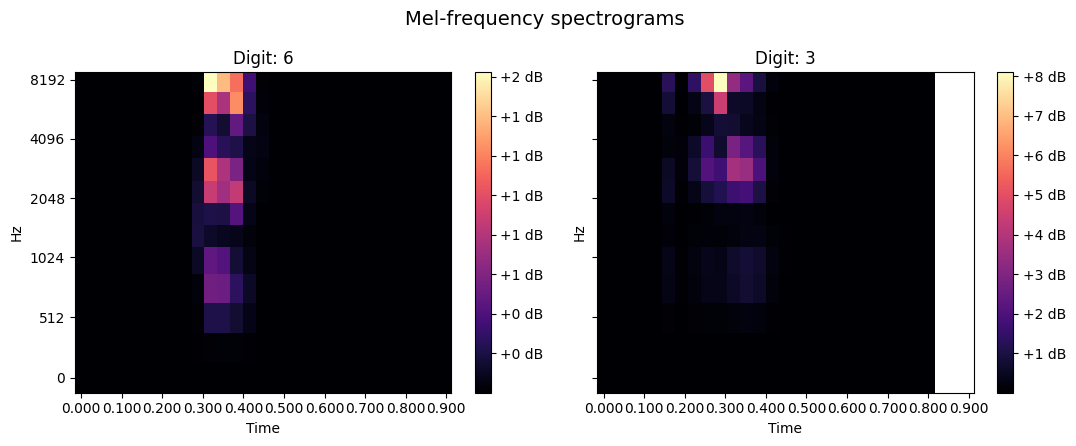

In [10]:
y1 = np.asarray(faudio[89][0])
y2 = np.asarray(faudio[103][0])
mel1 = librosa.feature.melspectrogram(y=y1, sr=16000, n_mels=128,fmax=16000,win_length=int(16000*25//1000))[0:13]
mel2 = librosa.feature.melspectrogram(y=y2, sr=16000, n_mels=128,fmax=16000,win_length=int(16000*25//1000))[0:13]

fig, ax = plt.subplots(1,2,figsize=(11,4.5), sharex=True, sharey=True)
fig.suptitle('Mel-frequency spectrograms', fontsize=14)

S_dB = librosa.power_to_db(mel1, ref=np.max)
img = librosa.display.specshow(mel1, x_axis='time',
                         y_axis='mel', sr=16000,
                         fmax=8000, ax=ax[0])
fig.colorbar(img, ax=ax[0], format='%+2.0f dB')
ax[0].set(title='Digit: '+str(n1))

S_dB2 = librosa.power_to_db(mel2, ref=np.max)
img = librosa.display.specshow(mel2, x_axis='time',
                         y_axis='mel', sr=16000,
                         fmax=8000, ax=ax[1])
fig.colorbar(img, ax=ax[1], format='%+2.0f dB')
ax[1].set(title='Digit: '+str(n2))

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'correlation matrix of mfcc for digit n2 speaker 1')

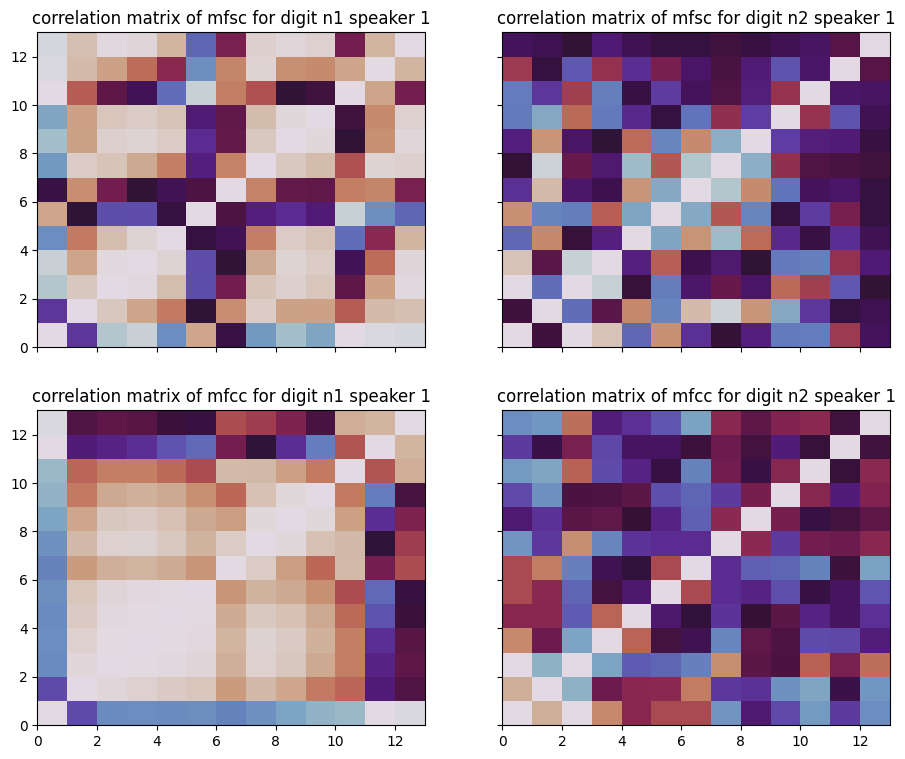

In [11]:
import pandas as pd
import seaborn as sn
def corrmatrix(S,title):
    
    df={str(i) : S[i] for i in range(13) }
    pd.Series(df).to_frame()
    df = pd.DataFrame(df)
    
    aa=df.corr()
    return aa

aa1=corrmatrix(mel1, "correlation matrix of mfsc for digit n1 speaker "+str(fspeaker[89]))
aa2=corrmatrix(frames[89], "correlation matrix of mfcc for digit n1 speaker "+str(fspeaker[89]))
aa3=corrmatrix(mel2, "correlation matrix of mfcc for digit n2 speaker "+str(fspeaker[103]))
aa4=corrmatrix(frames[103], "correlation matrix of mfcc for digit n2 speaker "+str(fspeaker[103]))

fig, ax = plt.subplots(2,2,figsize=(11,9), sharex=True, sharey=True)

ax[0,0].pcolormesh(aa1, cmap = 'twilight')
ax[0,0].set_title("correlation matrix of mfsc for digit n1 speaker "+str(fspeaker[89]))
ax[0,1].pcolormesh(aa2, cmap = 'twilight')
ax[0,1].set_title("correlation matrix of mfsc for digit n2 speaker "+str(fspeaker[89]))
ax[1,0].pcolormesh(aa3, cmap = 'twilight')
ax[1,0].set_title("correlation matrix of mfcc for digit n1 speaker "+str(fspeaker[103]))
ax[1,1].pcolormesh(aa4, cmap = 'twilight')
ax[1,1].set_title("correlation matrix of mfcc for digit n2 speaker "+str(fspeaker[103]))




Βήμα 5


(133, 78)
[-7.13827576e+02  1.01127655e+02 -3.36764793e+01  4.55965118e+01
  2.02996805e-01  3.41669893e+00 -2.51536608e-01 -9.35351372e+00
  3.49182320e+00 -9.25570679e+00 -4.01935530e+00 -1.37969449e-01
 -2.35408759e+00  1.97365605e+04  1.19331079e+03  2.81128906e+03
  1.51645850e+03  2.10342957e+02  8.46424408e+01  7.42333527e+01
  1.94955429e+02  2.20369614e+02  7.10566177e+01  1.16833977e+02
  6.33513680e+01  7.04270782e+01 -2.28805542e-02 -5.43815754e-02
  8.12948495e-02  1.45285487e-01  2.03191284e-02 -6.85633123e-02
 -5.24878502e-02  1.41397610e-01  1.18045807e-01 -2.57588383e-02
  3.20830308e-02  1.92097854e-02  2.68860962e-02  1.89509567e+02
  1.36663475e+01  3.19029732e+01  1.47041378e+01  5.01080465e+00
  1.51353514e+00  1.39995456e+00  2.58521056e+00  2.46480584e+00
  1.74049473e+00  1.89959955e+00  1.28740752e+00  1.32273912e+00
 -4.59364504e-02  3.65735255e-02  1.20993424e-02 -1.02845363e-01
 -7.43655562e-02 -5.15281707e-02  2.57207989e-03  3.15448525e-03
 -1.80532262e-0

Text(0.5, 1.0, 'Scatter Plot for First Two Dimensions')

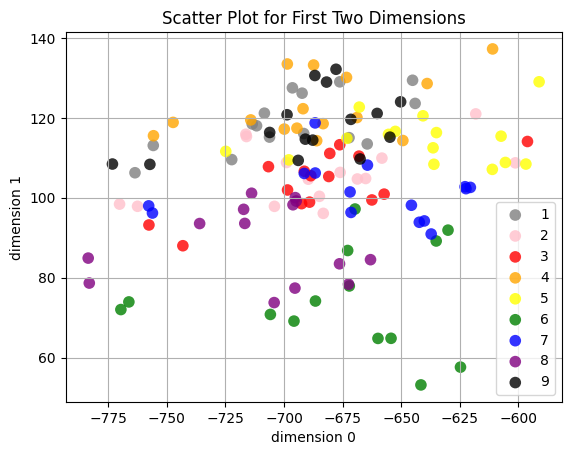

In [12]:
newX = []
for i in range(len(frames)):   
    newX.append(np.concatenate(( np.mean(frames[i],axis=1), np.var(frames[i],axis=1), 
            np.mean(delta_mfcc[i],axis=1), np.var(delta_mfcc[i],axis=1), 
                np.mean(delta2_mfcc[i],axis=1), np.var(delta2_mfcc[i],axis=1) ), axis=0)) 
newX = np.array(newX)
print(newX.shape)
print(newX[0])
newY = np.array(digit)
print(newY.shape)
print(newY[0])


dim0, dim1 = newX[:,0], newX[:,1]

colors = ['white','grey','pink','red','orange','yellow','green','blue','purple','black']
fig, ax = plt.subplots()
for label in range(1,10):

    ax.scatter(
        dim0[newY == label], dim1[newY == label], 
        c=(colors[int(label)]), label=int(label),
        s=70, alpha=0.8, edgecolors='None'
    )
ax.grid() 
ax.legend()
ax.set_xlabel('dimension 0')
ax.set_ylabel('dimension 1')
ax.set_title('Scatter Plot for First Two Dimensions')


Βήμα 6

Text(0.5, 1.0, 'Scatter Plot for PCA Analysis (n_components=2)')

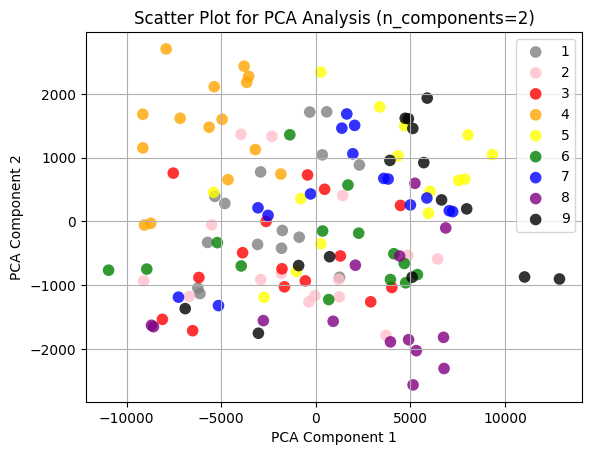

In [13]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(newX)

dim0, dim1 = principal_components[:,0], principal_components[:,1]

colors = ['white','grey','pink','red','orange','yellow','green','blue','purple','black']
fig, ax = plt.subplots()
for label in range(1,10):
    ax.scatter(
        dim0[newY == label], dim1[newY == label], 
        c=(colors[int(label)]), label=int(label),
        s=70, alpha=0.8, edgecolors='None'
    )
ax.grid()
ax.legend()
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_title('Scatter Plot for PCA Analysis (n_components=2)')


Text(0.5, 0.92, 'Scatter Plot for PCA Analysis (n_components=3)')

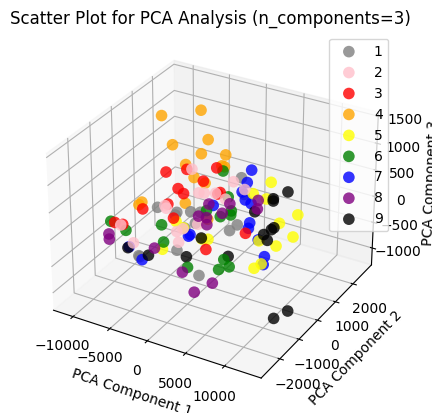

In [14]:
pca = PCA(n_components=3)
principal_components = pca.fit_transform(newX)

dim0, dim1, dim3 = principal_components[:,0], principal_components[:,1], principal_components[:,2]

colors = ['white','grey','pink','red','orange','yellow','green','blue','purple','black']
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
for label in range(1,10):
    ax.scatter(
        dim0[newY == label], dim1[newY == label], dim3[newY==label],
        c=(colors[int(label)]), label=int(label),
        s=70, alpha=0.8, edgecolors='None'
    )
 
ax.legend()
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('Scatter Plot for PCA Analysis (n_components=3)')


Βήμα 7

In [15]:
#Load Data
df = pd.DataFrame(faudio[0][0])
for i in range(len(faudio)):
    df.insert(i,"col"+str(i),pd.DataFrame(faudio[i][0]))
df = df.T
df.drop(df.tail(1).index,inplace=True)
df1 = pd.DataFrame(digit)
df1

/tmp/ipykernel_2318/1669612262.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(i,"col"+str(i),pd.DataFrame(faudio[i][0]))
/tmp/ipykernel_2318/1669612262.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df.insert(i,"col"+str(i),pd.DataFrame(faudio[i][0]))
/tmp/ipykernel_2318/1669612262.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a

,0
0,8
1,8
2,8
3,8
4,8
...,...
128,2
129,2
130,2
131,2


In [16]:
#Prepare data for the algorithm
#
for i in range(0,11891,1):
    temp = []
    n = df[i].isnull().values.any()
    if(n == True):
        temp.append(i)
#Pos diaferei apo to proigoumeno?
z = []
for i in range(0,11891):
   temp = df[i].isnull().values.any()
   if temp == True:
    z.append(i)
z

[8469,
 8470,
 8471,
 8472,
 8473,
 8474,
 8475,
 8476,
 8477,
 8478,
 8479,
 8480,
 8481,
 8482,
 8483,
 8484,
 8485,
 8486,
 8487,
 8488,
 8489,
 8490,
 8491,
 8492,
 8493,
 8494,
 8495,
 8496,
 8497,
 8498,
 8499,
 8500,
 8501,
 8502,
 8503,
 8504,
 8505,
 8506,
 8507,
 8508,
 8509,
 8510,
 8511,
 8512,
 8513,
 8514,
 8515,
 8516,
 8517,
 8518,
 8519,
 8520,
 8521,
 8522,
 8523,
 8524,
 8525,
 8526,
 8527,
 8528,
 8529,
 8530,
 8531,
 8532,
 8533,
 8534,
 8535,
 8536,
 8537,
 8538,
 8539,
 8540,
 8541,
 8542,
 8543,
 8544,
 8545,
 8546,
 8547,
 8548,
 8549,
 8550,
 8551,
 8552,
 8553,
 8554,
 8555,
 8556,
 8557,
 8558,
 8559,
 8560,
 8561,
 8562,
 8563,
 8564,
 8565,
 8566,
 8567,
 8568,
 8569,
 8570,
 8571,
 8572,
 8573,
 8574,
 8575,
 8576,
 8577,
 8578,
 8579,
 8580,
 8581,
 8582,
 8583,
 8584,
 8585,
 8586,
 8587,
 8588,
 8589,
 8590,
 8591,
 8592,
 8593,
 8594,
 8595,
 8596,
 8597,
 8598,
 8599,
 8600,
 8601,
 8602,
 8603,
 8604,
 8605,
 8606,
 8607,
 8608,
 8609,
 8610,
 8611,

In [17]:
#Calculate minimum value - but why? we use a estimetor from sklearn - what is this matrix?
#  -> he use it later
for i in range(len(z)):
    tm = np.mean(df[z[i]])
    q = np.where(df[z[i]].isnull())[0]
    for j in range(len(q)):
        df[z[i]][q[j]] = tm
df
dff = df
(dff - dff.min()) / (dff.max() - dff.min())

,0,1,2,3,4,5,6,7,8,9,...,11881,11882,11883,11884,11885,11886,11887,11888,11889,11890
col0,0.458065,0.290196,0.260684,0.323529,0.361345,0.374449,0.323404,0.294118,0.319549,0.390000,...,0.715573,0.674699,0.632212,0.493258,0.372881,0.318868,0.320856,0.334501,0.331650,0.312600
col1,0.541936,0.400000,0.290598,0.226891,0.184874,0.162996,0.127660,0.137255,0.206767,0.316667,...,0.700972,0.668996,0.642575,0.512247,0.393095,0.322348,0.309745,0.293073,0.281762,0.274286
col2,0.422581,0.262745,0.170940,0.180672,0.214286,0.233480,0.251064,0.305882,0.375940,0.470000,...,0.700972,0.668996,0.642575,0.512247,0.393095,0.322348,0.309745,0.293073,0.281762,0.274286
col3,0.545161,0.415686,0.333333,0.310924,0.315126,0.312775,0.280851,0.290196,0.357143,0.473333,...,0.700972,0.668996,0.642575,0.512247,0.393095,0.322348,0.309745,0.293073,0.281762,0.274286
col4,0.477419,0.345098,0.239316,0.201681,0.218487,0.224670,0.204255,0.231373,0.304511,0.420000,...,0.716860,0.674699,0.623798,0.485393,0.355932,0.288679,0.272727,0.257443,0.259259,0.264753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
col128,0.638710,0.494118,0.474359,0.550420,0.579832,0.577093,0.531915,0.494118,0.469925,0.480000,...,0.665380,0.640964,0.610577,0.486517,0.348399,0.266038,0.249554,0.238179,0.242424,0.247209
col129,0.532258,0.407843,0.350427,0.361345,0.365546,0.387665,0.378723,0.376471,0.417293,0.493333,...,0.716860,0.685542,0.643029,0.502247,0.370998,0.301887,0.290553,0.267951,0.249158,0.250399
col130,0.532258,0.407843,0.333333,0.302521,0.306723,0.321586,0.327660,0.341176,0.364662,0.443333,...,0.700972,0.668996,0.642575,0.512247,0.393095,0.322348,0.309745,0.293073,0.281762,0.274286
col131,0.454839,0.290196,0.209402,0.226891,0.235294,0.237885,0.234043,0.227451,0.278196,0.383333,...,0.745174,0.677108,0.655048,0.538202,0.410546,0.301887,0.297683,0.330998,0.383838,0.400319


In [18]:
# 1.import and use sklearn Gaussian Estimator
import sklearn as sk 
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


In [19]:

X_train, X_test, y_train, y_test = train_test_split(dff, df1, test_size=0.30)
estimator1 = GaussianNB()
estimator1.fit(X_train, y_train)
print("Succes Rate of GaussianNB Estimator for:\n")
print(estimator1.score(X_train, y_train))
print(estimator1.score(X_test, y_test))



/home/vd/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Succes Rate of GaussianNB Estimator for:

0.7849462365591398
0.325


In [20]:
# What's the reason for the train_split ??
X_train, X_test, y_train, y_test = train_test_split(df, df1, test_size=0.30)
estimator11 = GaussianNB()
estimator11.fit(X_train, y_train)
print("Succes Rate of GaussianNB Estimator after train_test_split the tfor:\n")
print(estimator1.score(X_train, y_train))
print(estimator1.score(X_test, y_test))

/home/vd/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Succes Rate of GaussianNB Estimator after train_test_split the tfor:

0.6451612903225806
0.65


In [21]:
# 2. Import and use LogisticRegrassion Estimator
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=0).fit(X_train, y_train)
print(clf.score(X_train,y_train))
print(clf.score(X_test,y_test))

/home/vd/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.956989247311828
0.125


In [22]:
# 3. Import and use Linear SVC Estimator
from sklearn.svm import LinearSVC
clf2 = LinearSVC()
clf2.fit(X_train,y_train)
print(clf2.score(X_train,y_train))
print(clf2.score(X_test,y_test))

/home/vd/.local/lib/python3.8/site-packages/sklearn/utils/validation.py:1111: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


1.0
0.2


Βήμα 8

In [23]:
import random
f=40
dt=0.01
N=20 # Number of cos and sin

Xc = np.zeros((N, 10))
Xs = np.zeros((N, 10))
time=np.linspace(0,3*np.pi/2,10)

for i in range(N):
    phi=np.random.rand()*2*np.pi
    A=np.random.rand()
    Xc[i,:]=A*np.cos(2*np.pi*f*time+phi)
    Xs[i,:]=A*np.cos(2*np.pi*f*time+np.pi/2+phi)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(Xs, Xc, test_size=0.30)

X_train = to.from_numpy(X_train)
y_train = to.from_numpy(y_train)
X_test = to.from_numpy(X_test)
y_test = to.from_numpy(y_test)

In [25]:
from torch import nn
import torch as to 

class LSTM(nn.Module):
    def __init__(self, x_size=1, hidden_layer_size=50, output_size=1):
        super(LSTM, self).__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTMCell(1, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, 1)

    def forward(self, x, future = 0):
        """ 
            x : 3D numpy array of dimension N x L x D
                N: batch index
                L: sequence index
                D: feature index
            lengths: N x 1-> x.size(0)
         """
        outputs = []
        h_t = to.zeros(x.size(0), self.hidden_layer_size, dtype=to.double)
        c_t = to.zeros(x.size(0), self.hidden_layer_size, dtype=to.double)
        """
            input (Tensor) – the tensor to split
            chunks (int) – number of chunks to return
            dim (int) – dimension along which to split the tensor
        """
        len=x.size(1)
        for i, x_t in enumerate(x.chunk(len, dim=1)):
            h_t, c_t = self.lstm(x_t, (h_t, c_t))
            output = self.linear(h_t)
            outputs += [output]
        outputs = to.stack(outputs, 1).squeeze(2)
        return outputs

In [26]:
model = LSTM().double()
criterion = nn.MSELoss()
optimizer = to.optim.Adam(model.parameters(), lr=0.001)

In [27]:
train_losses = []
test_losses = []

epochs = 1000
for i in range(epochs):
    optimizer.zero_grad()
    out = model(X_train)
    loss = criterion(out, y_train)
    if i%100 == 0:
        print('Train loss', 100*loss.item())
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    with to.no_grad():
        pred = model(X_test)
        loss = criterion(pred, y_test)
        if i%100 == 0:
            print('Test loss', 100*loss.item())
            print("\n")
        test_losses.append(loss.item())

Train loss 21.876567713102812
Test loss 19.305106691737006


Train loss 5.414032110318445
Test loss 10.513020245308345


Train loss 4.279730257025775
Test loss 9.047186507187316


Train loss 3.1339424508154328
Test loss 6.996373654759884


Train loss 2.4590681335293043
Test loss 5.599576236387067


Train loss 2.0103152801519473
Test loss 4.600753736421803


Train loss 1.7122021800073808
Test loss 3.9657191346184617


Train loss 1.493219550147996
Test loss 3.523393958905578


Train loss 1.341773455870815
Test loss 3.2257170386295706


Train loss 1.2196612412109298
Test loss 2.9827506295411856




Text(0, 0.5, '')

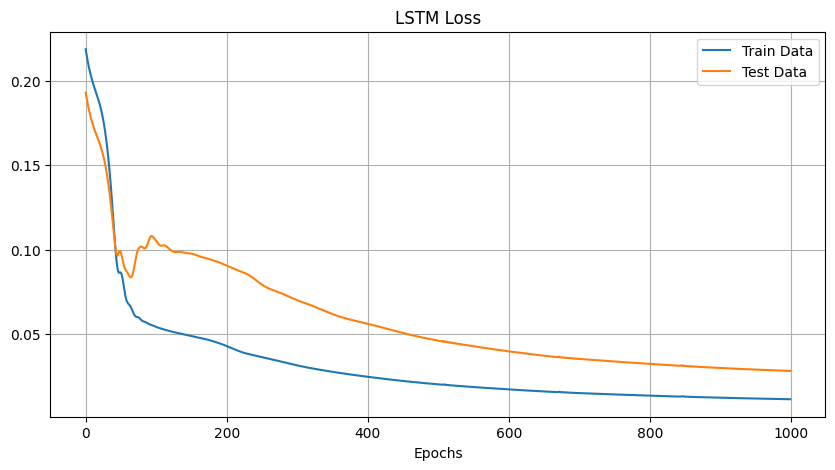

In [28]:
plt.rcParams['figure.figsize'] = [10, 5]
plt.plot(np.arange(len(train_losses)), train_losses)
plt.plot(np.arange(len(test_losses)), test_losses)
plt.title("LSTM Loss")
plt.grid()
plt.legend(["Train Data","Test Data"])
plt.xlabel("Epochs")
plt.ylabel("")